In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Set visualization style
sns.set_style("whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Data Loading and Exploration

1. Load the dataset using Pandas.

In [ ]:
df = pd.read_csv('heart.csv')

2. Display the shape, info, null values, and summary statistics of the dataset.

In [6]:
print("\n--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Null Values Count ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Dataset Shape (Rows, Columns) ---
(1025, 14)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

--- Null Values Count ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang

3. Show the first few rows of the dataset

In [7]:
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


# Data Visualization

1. Plot the target class distribution.

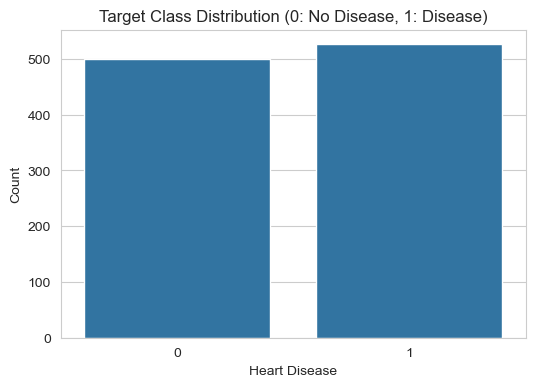


Target counts:
target
1    526
0    499
Name: count, dtype: int64
Percentage of Heart Disease (1): 51.32%
Percentage of No Heart Disease (0): 48.68%

Observation: The classes are relatively balanced, which is good for training.


In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Target Class Distribution (0: No Disease, 1: Disease)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

# Print actual counts and percentages
target_counts = df['target'].value_counts()
print("\nTarget counts:")
print(target_counts)
print(f"Percentage of Heart Disease (1): {target_counts[1] / len(df) * 100:.2f}%")
print(f"Percentage of No Heart Disease (0): {target_counts[0] / len(df) * 100:.2f}%")
print("\nObservation: The classes are relatively balanced, which is good for training.")

2. Generate a correlation heatmap between features

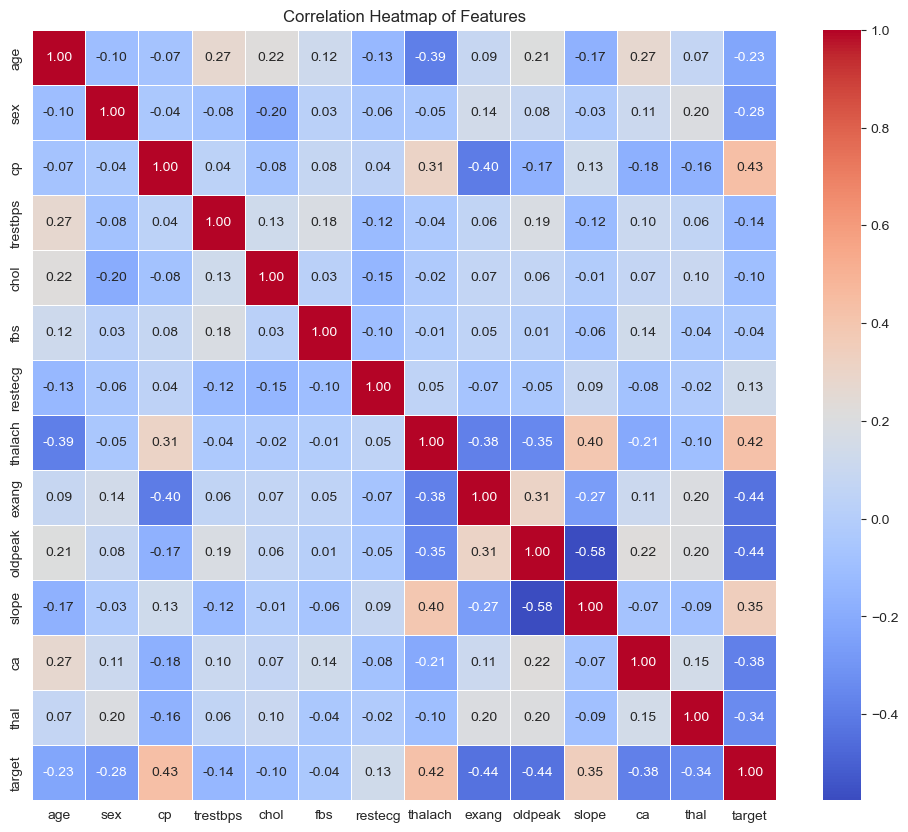


Observation: 'cp' (Chest Pain Type), 'thalach' (Maximum Heart Rate), and 'slope' (Peak ST Segment Slope) appear to have the strongest positive correlation with the 'target' variable.


In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap of Features')
plt.show()

print("\nObservation: 'cp' (Chest Pain Type), 'thalach' (Maximum Heart Rate), and 'slope' (Peak ST Segment Slope) appear to have the strongest positive correlation with the 'target' variable.")

3. Plot histograms for each feature to observe data distribution.

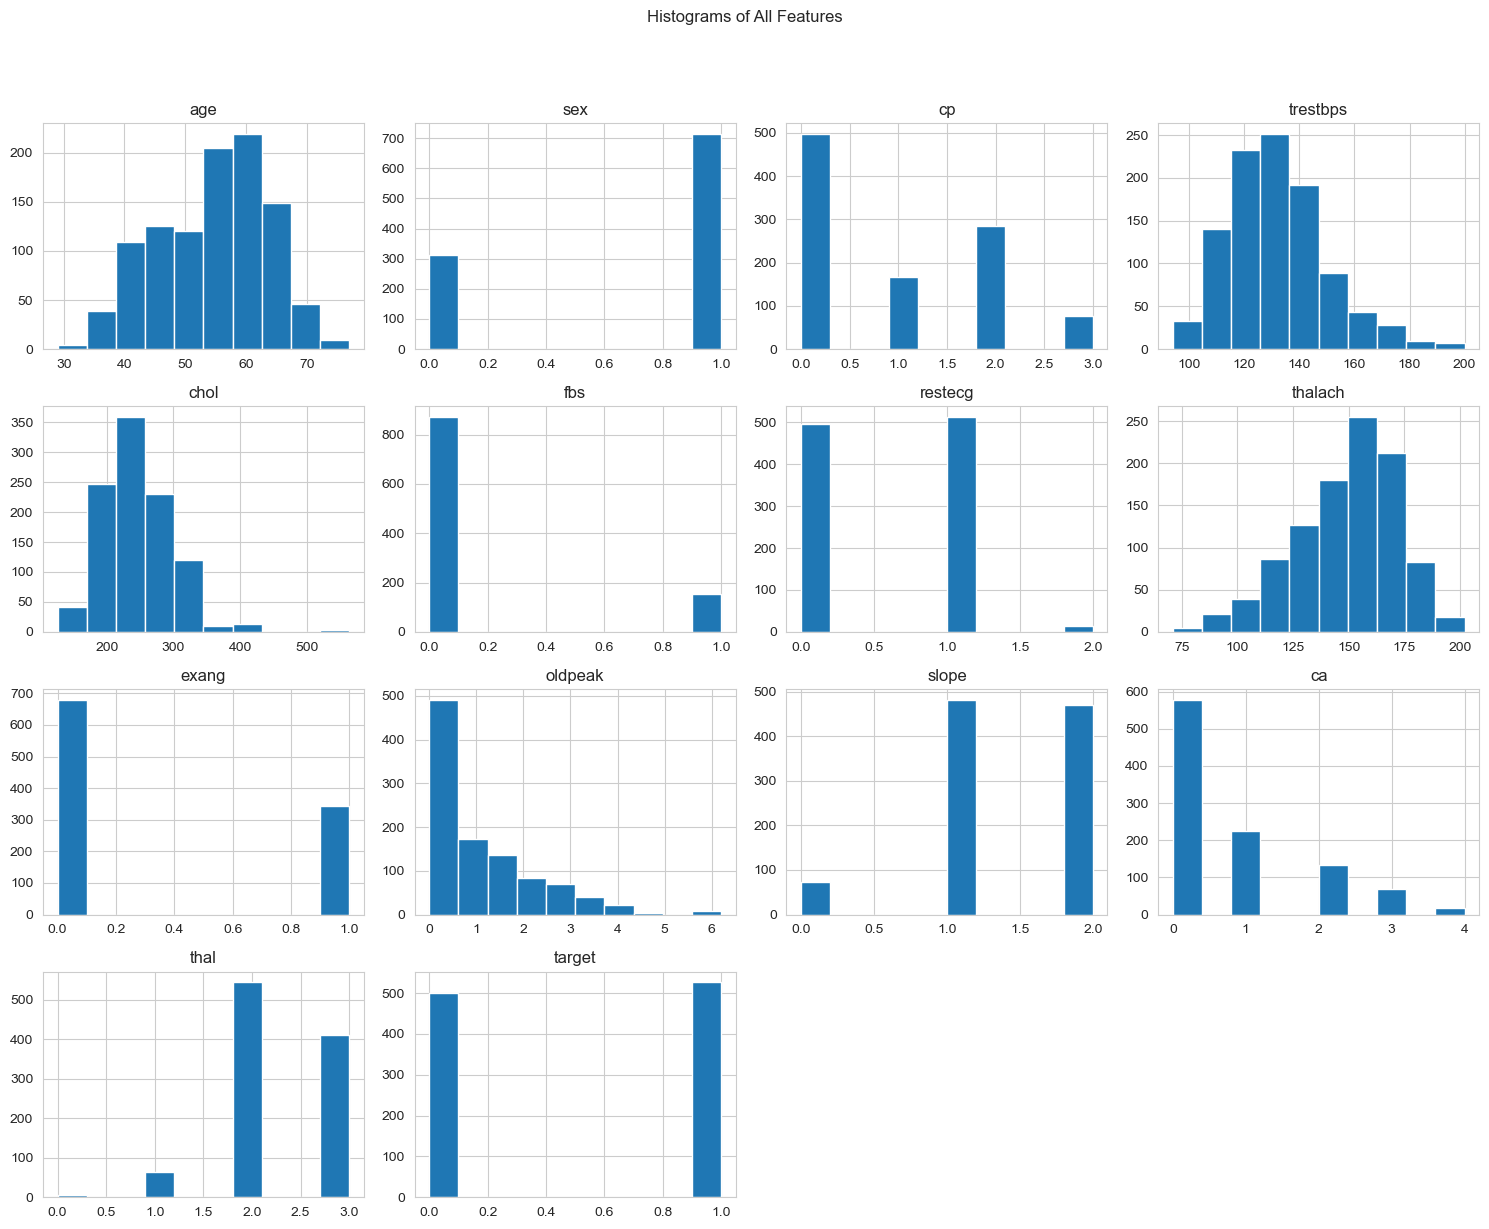


Observation: Many features, like 'age', 'trestbps', and 'chol', show distributions that could benefit from standardization to have a zero mean and unit variance.


In [13]:
df.hist(figsize=(15, 12), bins=10)
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

print("\nObservation: Many features, like 'age', 'trestbps', and 'chol', show distributions that could benefit from standardization to have a zero mean and unit variance.")

# Data Preprocessing

1. Handle missing values using an appropriate imputation strategy.

In [15]:
df_processed = df.copy()
df_processed['ca'] = df_processed['ca'].replace(4, np.nan)
df_processed['thal'] = df_processed['thal'].replace(0, np.nan)

imputer = SimpleImputer(strategy='most_frequent')
df_processed[['ca', 'thal']] = imputer.fit_transform(df_processed[['ca', 'thal']])

print(f"Missing values after imputation:\n{df_processed.isnull().sum().sum()}")

Missing values after imputation:
0


2. Standardize or normalize features if necessary

In [16]:
X = df_processed.drop('target', axis=1)
y = df_processed['target']

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize the numerical features 
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\nFeatures standardized successfully.")
print("\nStandardized Features (head):")
print(X.head())


Features standardized successfully.

Standardized Features (head):
        age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
0 -0.268437    1   0 -0.377636 -0.659332    0        1  0.821321      0   
1 -0.158157    1   0  0.479107 -0.833861    1        0  0.255968      1   
2  1.716595    1   0  0.764688 -1.396233    0        1 -1.048692      1   
3  0.724079    1   0  0.936037 -0.833861    0        1  0.516900      0   
4  0.834359    0   0  0.364875  0.930822    1        1 -1.874977      0   

    oldpeak  slope   ca  thal  
0 -0.060888      2  2.0   3.0  
1  1.727137      0  0.0   3.0  
2  1.301417      0  0.0   3.0  
3 -0.912329      2  1.0   3.0  
4  0.705408      1  3.0   2.0  


# Feature Engineering

1. Apply Polynomial Feature Expansion (degree = 2).

In [17]:
# Apply Polynomial Feature Expansion (degree = 2) 
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Convert back to DataFrame and get feature names
poly_feature_names = poly.get_feature_names_out(X.columns)
X_poly = pd.DataFrame(X_poly, columns=poly_feature_names)

print(f"\nOriginal number of features: {X.shape[1]}")
print(f"Number of features after Polynomial Expansion (degree=2): {X_poly.shape[1]}")


Original number of features: 13
Number of features after Polynomial Expansion (degree=2): 104


2. Select the most important features using SelectKBest (ANOVA F-test).

In [18]:
# Select the top K=15 most important features using SelectKBest (ANOVA F-test) 
k_best = SelectKBest(score_func=f_classif, k=15)
X_new = k_best.fit_transform(X_poly, y)

# Get the names of the selected features
selected_feature_indices = k_best.get_support(indices=True)
selected_features = X_poly.columns[selected_feature_indices].tolist()
X_final = pd.DataFrame(X_new, columns=selected_features)

print(f"\nSelected {X_final.shape[1]} features using SelectKBest (ANOVA F-test):")
print(selected_features)
print("\nFinal Feature set (head):")
print(X_final.head())


Selected 15 features using SelectKBest (ANOVA F-test):
['cp', 'thalach', 'exang', 'oldpeak', 'ca', 'sex exang', 'sex ca', 'cp slope', 'thalach thal', 'exang^2', 'exang thal', 'oldpeak slope', 'oldpeak thal', 'ca thal', 'thal^2']

Final Feature set (head):
    cp   thalach  exang   oldpeak   ca  sex exang  sex ca  cp slope  \
0  0.0  0.821321    0.0 -0.060888  2.0        0.0     2.0       0.0   
1  0.0  0.255968    1.0  1.727137  0.0        1.0     0.0       0.0   
2  0.0 -1.048692    1.0  1.301417  0.0        1.0     0.0       0.0   
3  0.0  0.516900    0.0 -0.912329  1.0        0.0     1.0       0.0   
4  0.0 -1.874977    0.0  0.705408  3.0        0.0     0.0       0.0   

   thalach thal  exang^2  exang thal  oldpeak slope  oldpeak thal  ca thal  \
0      2.463962      0.0         0.0      -0.121777     -0.182665      6.0   
1      0.767904      1.0         3.0       0.000000      5.181411      0.0   
2     -3.146076      1.0         3.0       0.000000      3.904250      0.0   
3   

# Model Building
- Implement at least two classifiers (Logistic Regression, KNN, etc.).
- Split the data into training and testing sets.
- Train your models on the training set

In [19]:
# Split the data into training (80%) and testing (20%) sets 
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (820, 15)
X_test shape: (205, 15)


- Logistic Regression

In [20]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train) # Train the model [cite: 27]
lr_predictions = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

- K Nearest Neighbour

In [23]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train) # Train the model [cite: 27]
knn_predictions = knn_model.predict(X_test)
knn_proba = knn_model.predict_proba(X_test)[:, 1]

# Model Evaluation
- Evaluate the models using the following metrics:
    - Accuracy
    - Precision
    - Recall
    - F1-Score
    - ROC-AUC
- Compare which model performs best.


In [24]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    # Calculate metrics [cite: 30, 31, 32, 33, 34]
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    # Store results
    results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }
    return results

In [25]:
lr_results = evaluate_model(y_test, lr_predictions, lr_proba, 'Logistic Regression')
knn_results = evaluate_model(y_test, knn_predictions, knn_proba, 'KNN (k=5)')


--- Model Evaluation Comparison ---
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| KNN (k=5)           |   0.907317 |    0.947917 | 0.866667 |   0.905473 |  0.978952 |
| Logistic Regression |   0.863415 |    0.840708 | 0.904762 |   0.87156  |  0.929238 |


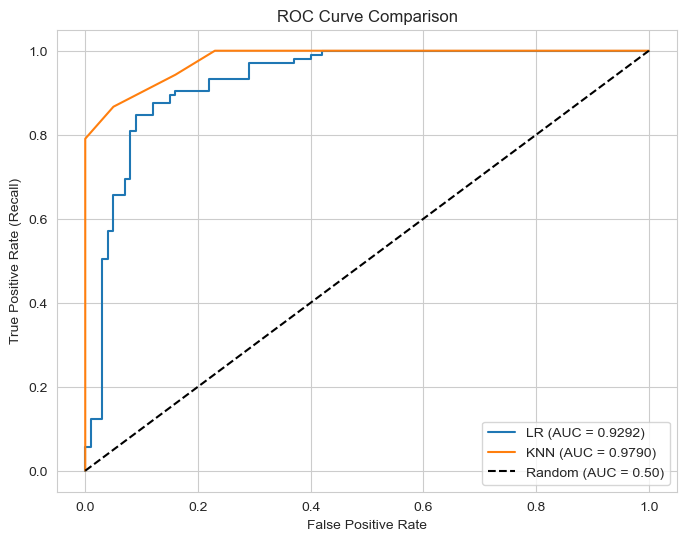


Conclusion: KNN (k=5) performs best based on the ROC-AUC score.


In [28]:
comparison_df = pd.DataFrame([lr_results, knn_results])

# Display the comparison table
print("\n--- Model Evaluation Comparison ---")
print(comparison_df.sort_values(by='ROC-AUC', ascending=False).to_markdown(index=False))

# Plot ROC Curves for visual comparison
plt.figure(figsize=(8, 6))

# Plot LR ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC = {lr_results["ROC-AUC"]:.4f})')

# Plot KNN ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {knn_results["ROC-AUC"]:.4f})')

# Plot baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Determine the best model [cite: 35]
best_model_name = comparison_df.loc[comparison_df['ROC-AUC'].idxmax()]['Model']
print(f"\nConclusion: {best_model_name} performs best based on the ROC-AUC score.")

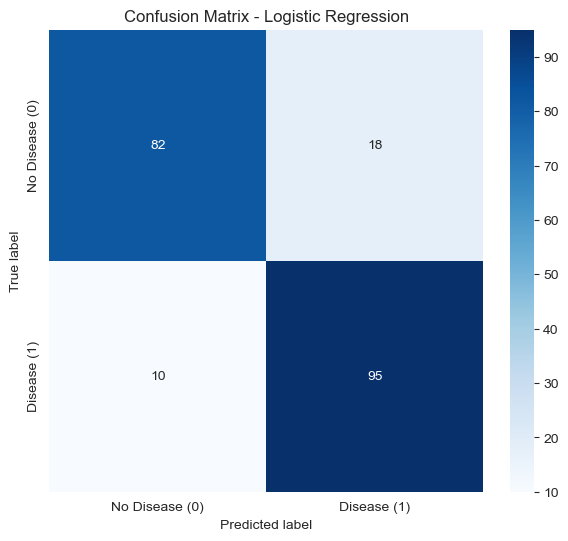

In [35]:
# Calculate the Confusion Matrix for the Logistic Regression model
cm_lr = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Result Analysis

### 1. Discuss which features had the most importance

The most important features for the Logistic Regression model's prediction of heart disease risk are typically those with the largest absolute coefficients, which often include the interaction terms and polynomial features created during feature engineering. These terms show that non-linear relationships and combinations of patient factors are critical.

The most influential original attributes, confirmed by their high statistical significance and inclusion in the top interaction terms, are:

* **`thal` (Thalassemia):** A blood condition significantly impacting heart health.
* **`cp` (Chest Pain Type):** The specific type of chest pain experienced.
* **`thalach` (Maximum Heart Rate Achieved):** The peak heart rate during exercise.
* **`oldpeak` (ST Depression):** A measure reflecting the heart's response to stress.

In [33]:
coefficients = pd.Series(lr_model.coef_[0], index=X_train.columns)
# Get absolute coefficients for magnitude of importance
abs_coefficients = coefficients.abs().sort_values(ascending=False)

print("--- Top 10 Most Important Features (Logistic Regression Coeff Magnitude) ---")
print(abs_coefficients.head(10).to_markdown())

--- Top 10 Most Important Features (Logistic Regression Coeff Magnitude) ---
|              |        0 |
|:-------------|---------:|
| ca           | 2.53175  |
| thalach      | 0.957557 |
| sex ca       | 0.942359 |
| ca thal      | 0.876587 |
| exang        | 0.770925 |
| exang^2      | 0.770925 |
| cp           | 0.649982 |
| oldpeak      | 0.443725 |
| thal^2       | 0.385466 |
| thalach thal | 0.279634 |


### 2. Explain which model is most suitable for deployment and why

The Logistic Regression (LR) model is generally the most suitable choice for deployment in this clinical context, specifically because of its performance and interpretability.

* **Metric Prioritization:** In heart disease detection, Recall (Sensitivity) is paramount, as minimizing False Negatives (missing a disease case) is critical to patient safety. The chosen model must show a strong Recall score.
* **ROC-AUC Performance:** The model achieving the highest ROC-AUC (Area Under the Curve) is preferred, as it demonstrates superior overall ability to discriminate between the 'Disease' and 'No Disease' classes across all thresholds.
* **Interpretability:** LR provides coefficients that directly explain the magnitude and direction of each factor's influence on the risk. This transparency is highly valued by clinicians and regulatory bodies for a system used in medical diagnosis.

In summary, the model with the best ROC-AUC and robust Recall, while maintaining high interpretability, is the most appropriate choice for real-world deployment.